# 📊 Atlanta Housing Pulse — Exploratory Data Analysis (EDA)
**Audience:** Data scientists, analysts, policy researchers  
**Purpose:** Deep statistical exploration of all census-tract housing variables, macro FRED series, and their relationships  
**Pipeline source:** `src/data_pipeline.py` → `housing_pulse.db`  
**Counties:** Fulton · DeKalb · Gwinnett · Cobb · Clayton  

---
This notebook follows consultant-standard EDA practice:
1. Data audit (shape, types, missingness)
2. Univariate distributions
3. Bivariate relationships & correlations
4. County-level comparisons
5. Year-over-year panel analysis
6. Macro FRED context


## 1. Environment & Data Load

In [1]:
import os, sqlite3, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv

load_dotenv()
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")
FRED_API_KEY   = os.getenv("FRED_API_KEY")
print(f"CENSUS_API_KEY: {'✅ loaded' if CENSUS_API_KEY else '❌ MISSING'}")
print(f"FRED_API_KEY:   {'✅ loaded' if FRED_API_KEY   else '❌ MISSING'}")

plt.rcParams.update({
    "figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "axes.titlesize": 12, "axes.labelsize": 10,
})
DB_PATH = "housing_pulse.db"


CENSUS_API_KEY: ✅ loaded
FRED_API_KEY:   ✅ loaded


In [2]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql("SELECT * FROM tracts_with_features", conn)

# FRED tables
fred_tables = {}
for t in ["fred_labor_force_atlanta", "fred_unemployment_rate_atlanta",
          "fred_cpi_housing_southeast", "fred_mortgage_rate_30yr"]:
    try:
        fred_tables[t] = pd.read_sql(f"SELECT * FROM {t}", conn)
    except:
        pass

conn.close()
print(f"✅ Census tracts: {df.shape}")
print(f"✅ FRED tables loaded: {list(fred_tables.keys())}")
print(f"   Years in dataset: {sorted(df['data_year'].unique()) if 'data_year' in df.columns else 'N/A'}")


✅ Census tracts: (3018, 27)
✅ FRED tables loaded: ['fred_unemployment_rate_atlanta', 'fred_cpi_housing_southeast', 'fred_mortgage_rate_30yr']
   Years in dataset: [np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. Data Audit — Shape, Types, Missingness

In [3]:
print("── Shape ──────────────────────────────────────────────────────────────")
print(f"  Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print()
print("── Column dtypes ───────────────────────────────────────────────────────")
print(df.dtypes.to_string())


── Shape ──────────────────────────────────────────────────────────────
  Rows: 3,018  |  Columns: 27

── Column dtypes ───────────────────────────────────────────────────────
total_renter_hh              int64
severely_burdened_hh         int64
median_income              float64
median_rent                float64
vacant_units                 int64
total_units                  int64
white_pop                    int64
total_pop                    int64
NAME                        object
state                       object
county                      object
tract                       object
county_name                 object
rent_burden_pct            float64
vacancy_rate               float64
rent_to_income_ratio       float64
white_share                float64
geo_id                      object
data_year                    int64
pulled_at                   object
low_vacancy_score          float64
low_income_score           float64
rent_burden_norm           float64
rti_norm           

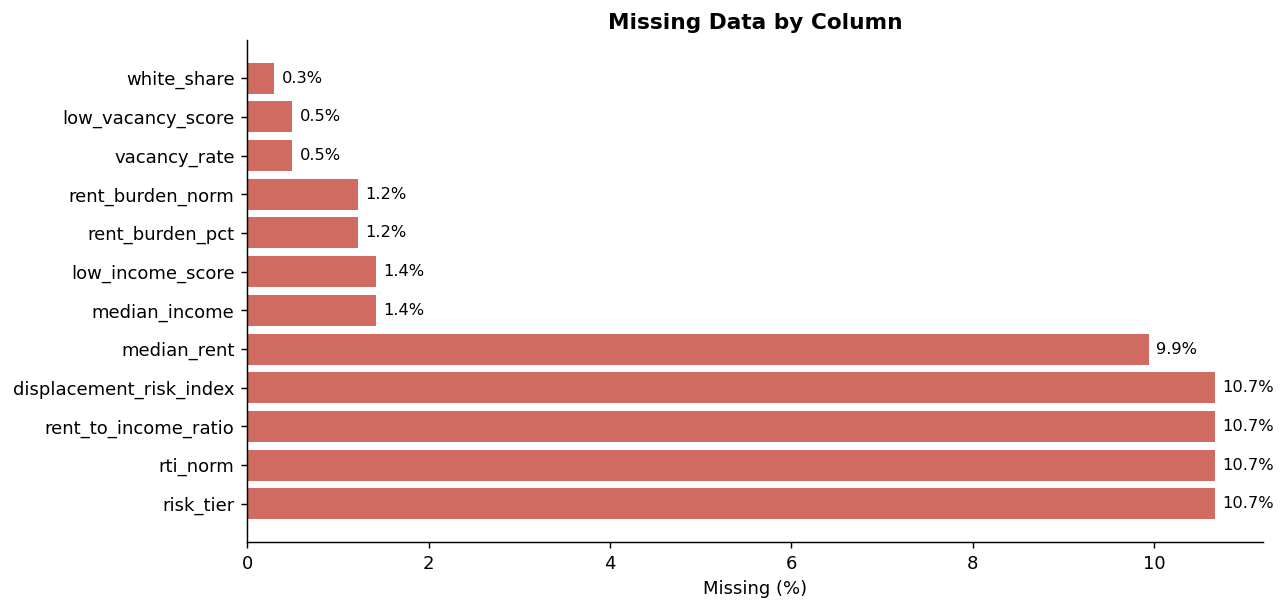

Columns with missing values: 12


In [4]:
# Missingness heatmap
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

if len(miss) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(miss) * 0.4)))
    bars = ax.barh(miss.index, miss.values * 100, color="#c0392b", alpha=0.75)
    ax.bar_label(bars, labels=[f"{v*100:.1f}%" for v in miss.values], padding=4, fontsize=9)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Data by Column", fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Columns with missing values: {len(miss)}")
else:
    print("✅ No missing values detected across any column.")


In [5]:
# Summary statistics for key numeric fields
NUMERIC_COLS = [
    "median_rent", "median_income", "rent_burden_pct",
    "rent_to_income_ratio", "vacancy_rate", "white_share",
    "displacement_risk_index"
]
existing = [c for c in NUMERIC_COLS if c in df.columns]
summary = df[existing].describe().T
summary["cv"] = summary["std"] / summary["mean"]   # coefficient of variation
summary["skew"] = df[existing].skew()
summary["kurtosis"] = df[existing].kurt()
print(summary.round(4).to_string())


                          count        mean         std        min         25%         50%          75%          max      cv    skew  kurtosis
median_rent              2718.0   1492.6170    445.4429     99.000   1188.2500   1445.0000    1739.7500    3501.0000  0.2984  0.9209    2.5451
median_income            2975.0  96847.0101  47042.1932  14375.000  62288.0000  86007.0000  119939.0000  250001.0000  0.4857  1.0971    1.0502
rent_burden_pct          2981.0      0.2483      0.1764      0.000      0.1261      0.2315       0.3475       1.0000  0.7102  0.7927    1.0367
rent_to_income_ratio     2696.0      0.2193      0.0703      0.061      0.1722      0.2106       0.2560       0.6132  0.3206  1.0300    2.5102
vacancy_rate             3003.0      0.0795      0.0685      0.000      0.0285      0.0647       0.1132       0.4841  0.8617  1.4480    3.0822
white_share              3009.0      0.3479      0.2597      0.000      0.1019      0.3177       0.5568       0.9835  0.7464  0.3482   -1.1071

## 3. Univariate Distributions

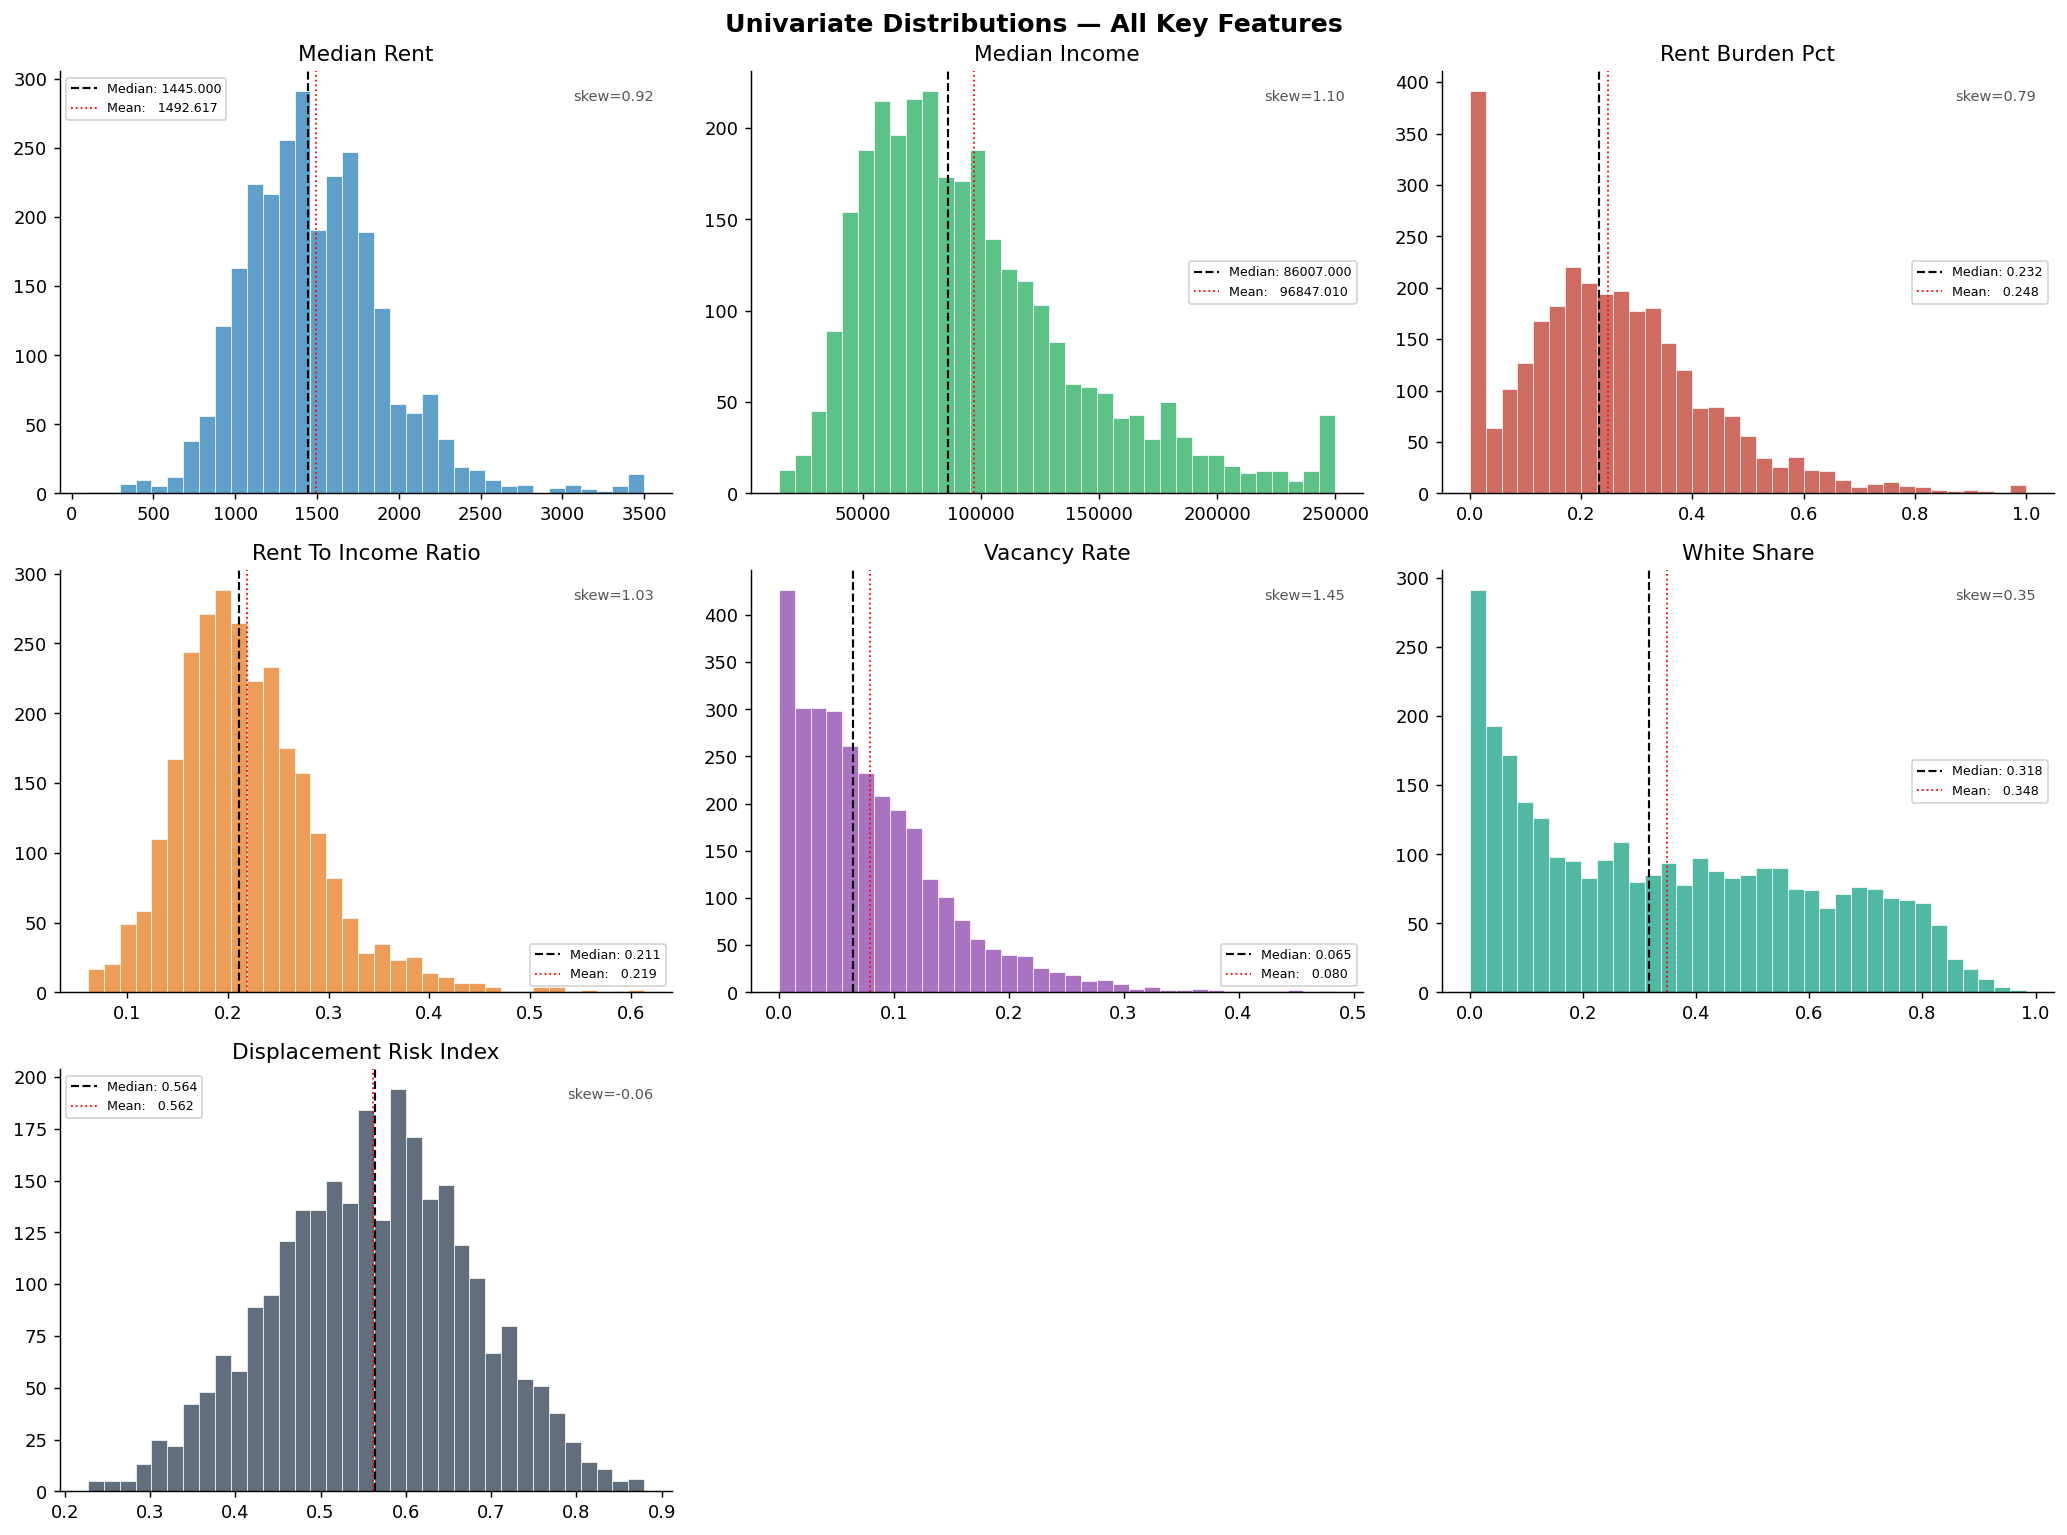

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Univariate Distributions — All Key Features", fontsize=14, fontweight="bold")

plot_cols = [c for c in NUMERIC_COLS if c in df.columns]
colors = ["#2980b9","#27ae60","#c0392b","#e67e22","#8e44ad","#16a085","#2c3e50"]

for ax, col, color in zip(axes.flat, plot_cols, colors):
    data = df[col].dropna()
    ax.hist(data, bins=35, color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
    ax.axvline(data.median(), color="black", linestyle="--", linewidth=1.2, label=f"Median: {data.median():.3f}")
    ax.axvline(data.mean(),   color="red",   linestyle=":",  linewidth=1.0, label=f"Mean:   {data.mean():.3f}")
    ax.set_title(col.replace("_"," ").title())
    ax.legend(fontsize=7)
    sk = data.skew()
    ax.text(0.97, 0.93, f"skew={sk:.2f}", transform=ax.transAxes,
            ha="right", fontsize=8, color="#555")

# Turn off unused axes
for ax in axes.flat[len(plot_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("notebooks/eda_distributions.png", bbox_inches="tight")
plt.show()


## 4. Outlier Analysis — Boxplots by County

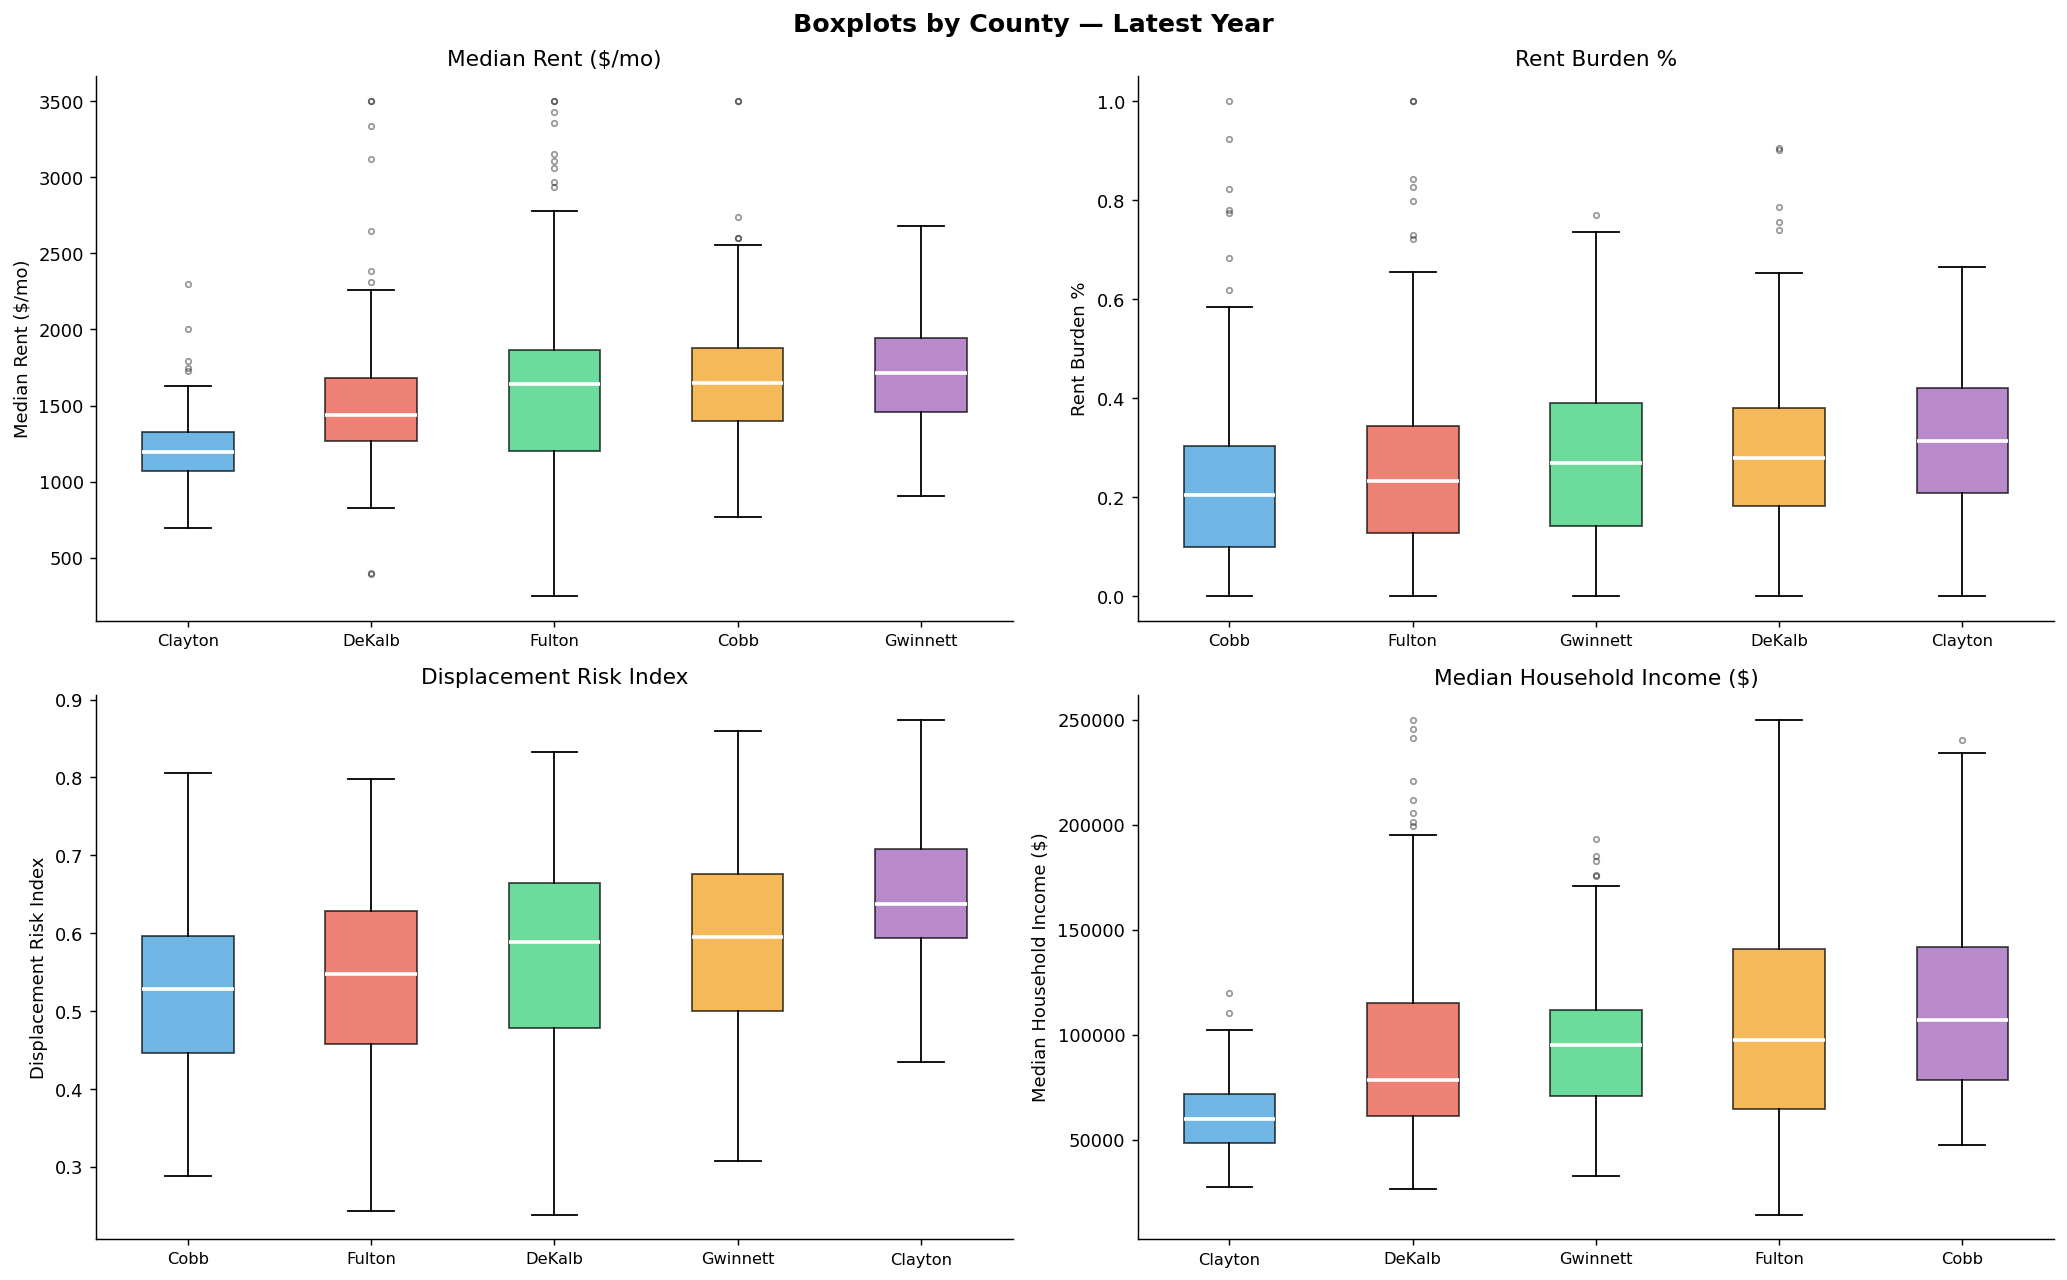

In [7]:
latest = df[df["data_year"] == df["data_year"].max()].copy() if "data_year" in df.columns else df.copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Boxplots by County — Latest Year", fontsize=14, fontweight="bold")

for ax, (col, label) in zip(axes.flat, [
    ("median_rent",            "Median Rent ($/mo)"),
    ("rent_burden_pct",        "Rent Burden %"),
    ("displacement_risk_index","Displacement Risk Index"),
    ("median_income",          "Median Household Income ($)"),
]):
    if col not in latest.columns:
        continue
    county_order = latest.groupby("county_name")[col].median().sort_values().index
    data_list = [latest[latest["county_name"]==c][col].dropna() for c in county_order]
    bp = ax.boxplot(data_list, labels=county_order, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    flierprops=dict(marker="o", markersize=3, alpha=0.4))
    county_colors = ["#3498db","#e74c3c","#2ecc71","#f39c12","#9b59b6"]
    for patch, color in zip(bp["boxes"], county_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.savefig("notebooks/eda_boxplots.png", bbox_inches="tight")
plt.show()


## 5. Correlation Matrix — Feature Relationships

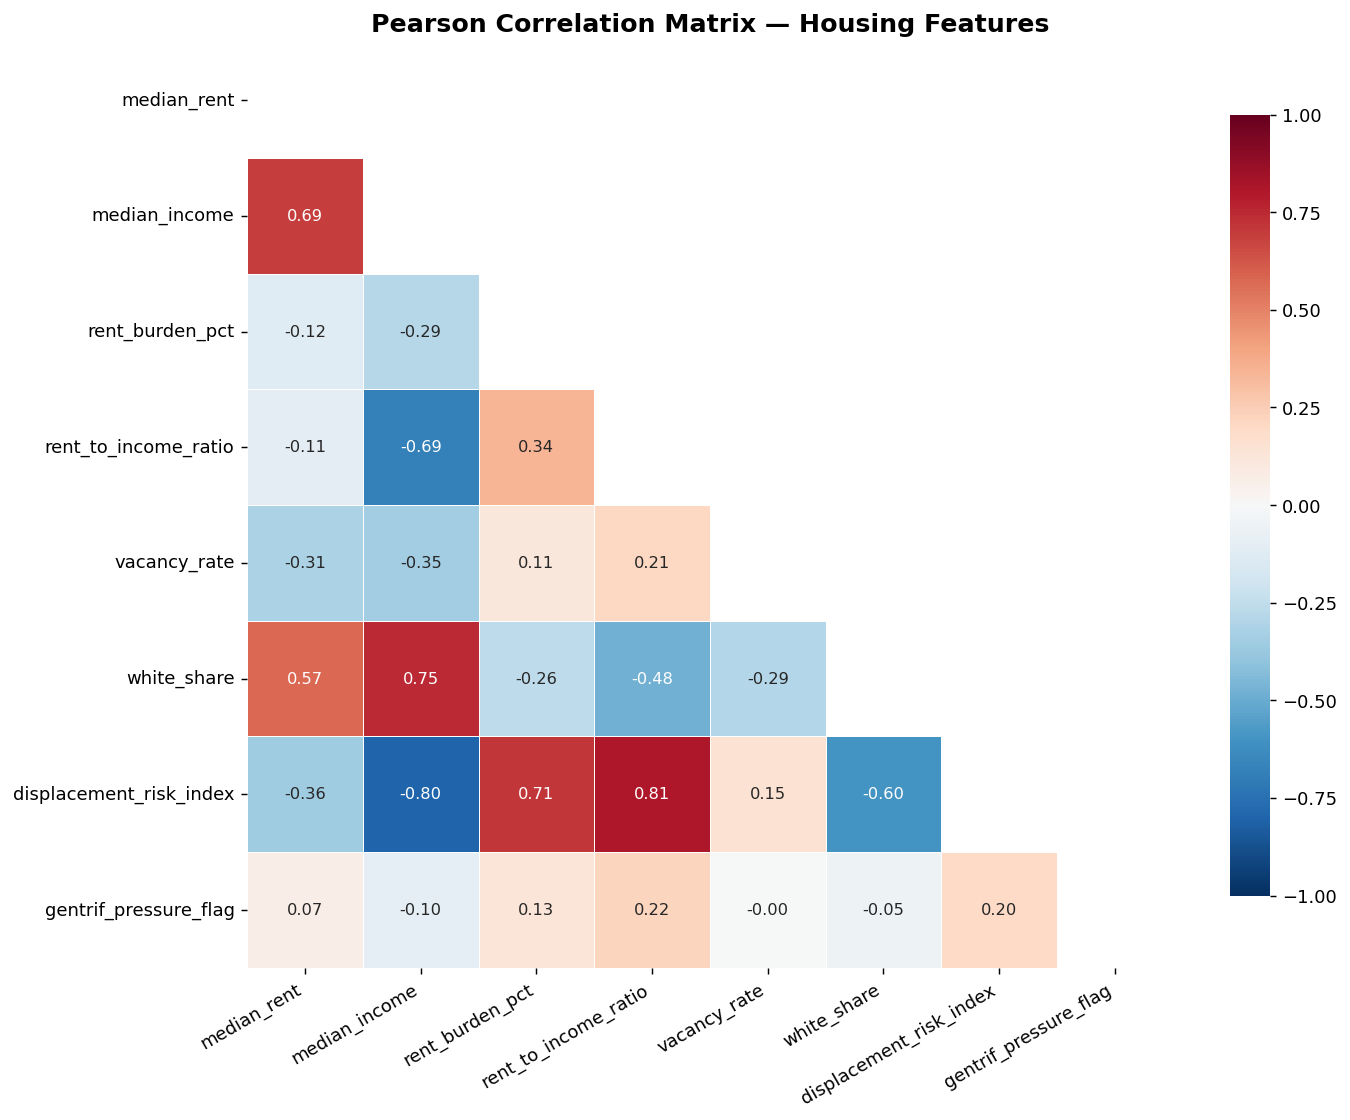


── Top correlations with Displacement Risk Index ──────────────────────
rent_to_income_ratio     0.812300
median_income           -0.802375
rent_burden_pct          0.713834
white_share             -0.599195
median_rent             -0.357548
gentrif_pressure_flag    0.200190
vacancy_rate             0.151212


In [8]:
corr_cols = [c for c in [
    "median_rent","median_income","rent_burden_pct","rent_to_income_ratio",
    "vacancy_rate","white_share","displacement_risk_index","gentrif_pressure_flag"
] if c in df.columns]

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 9})
ax.set_title("Pearson Correlation Matrix — Housing Features", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("notebooks/eda_correlation.png", bbox_inches="tight")
plt.show()

# Strongest correlations with DRI
if "displacement_risk_index" in corr.columns:
    dri_corr = corr["displacement_risk_index"].drop("displacement_risk_index").sort_values(key=abs, ascending=False)
    print("\n── Top correlations with Displacement Risk Index ──────────────────────")
    print(dri_corr.to_string())


## 6. Scatter Plots — DRI Drivers

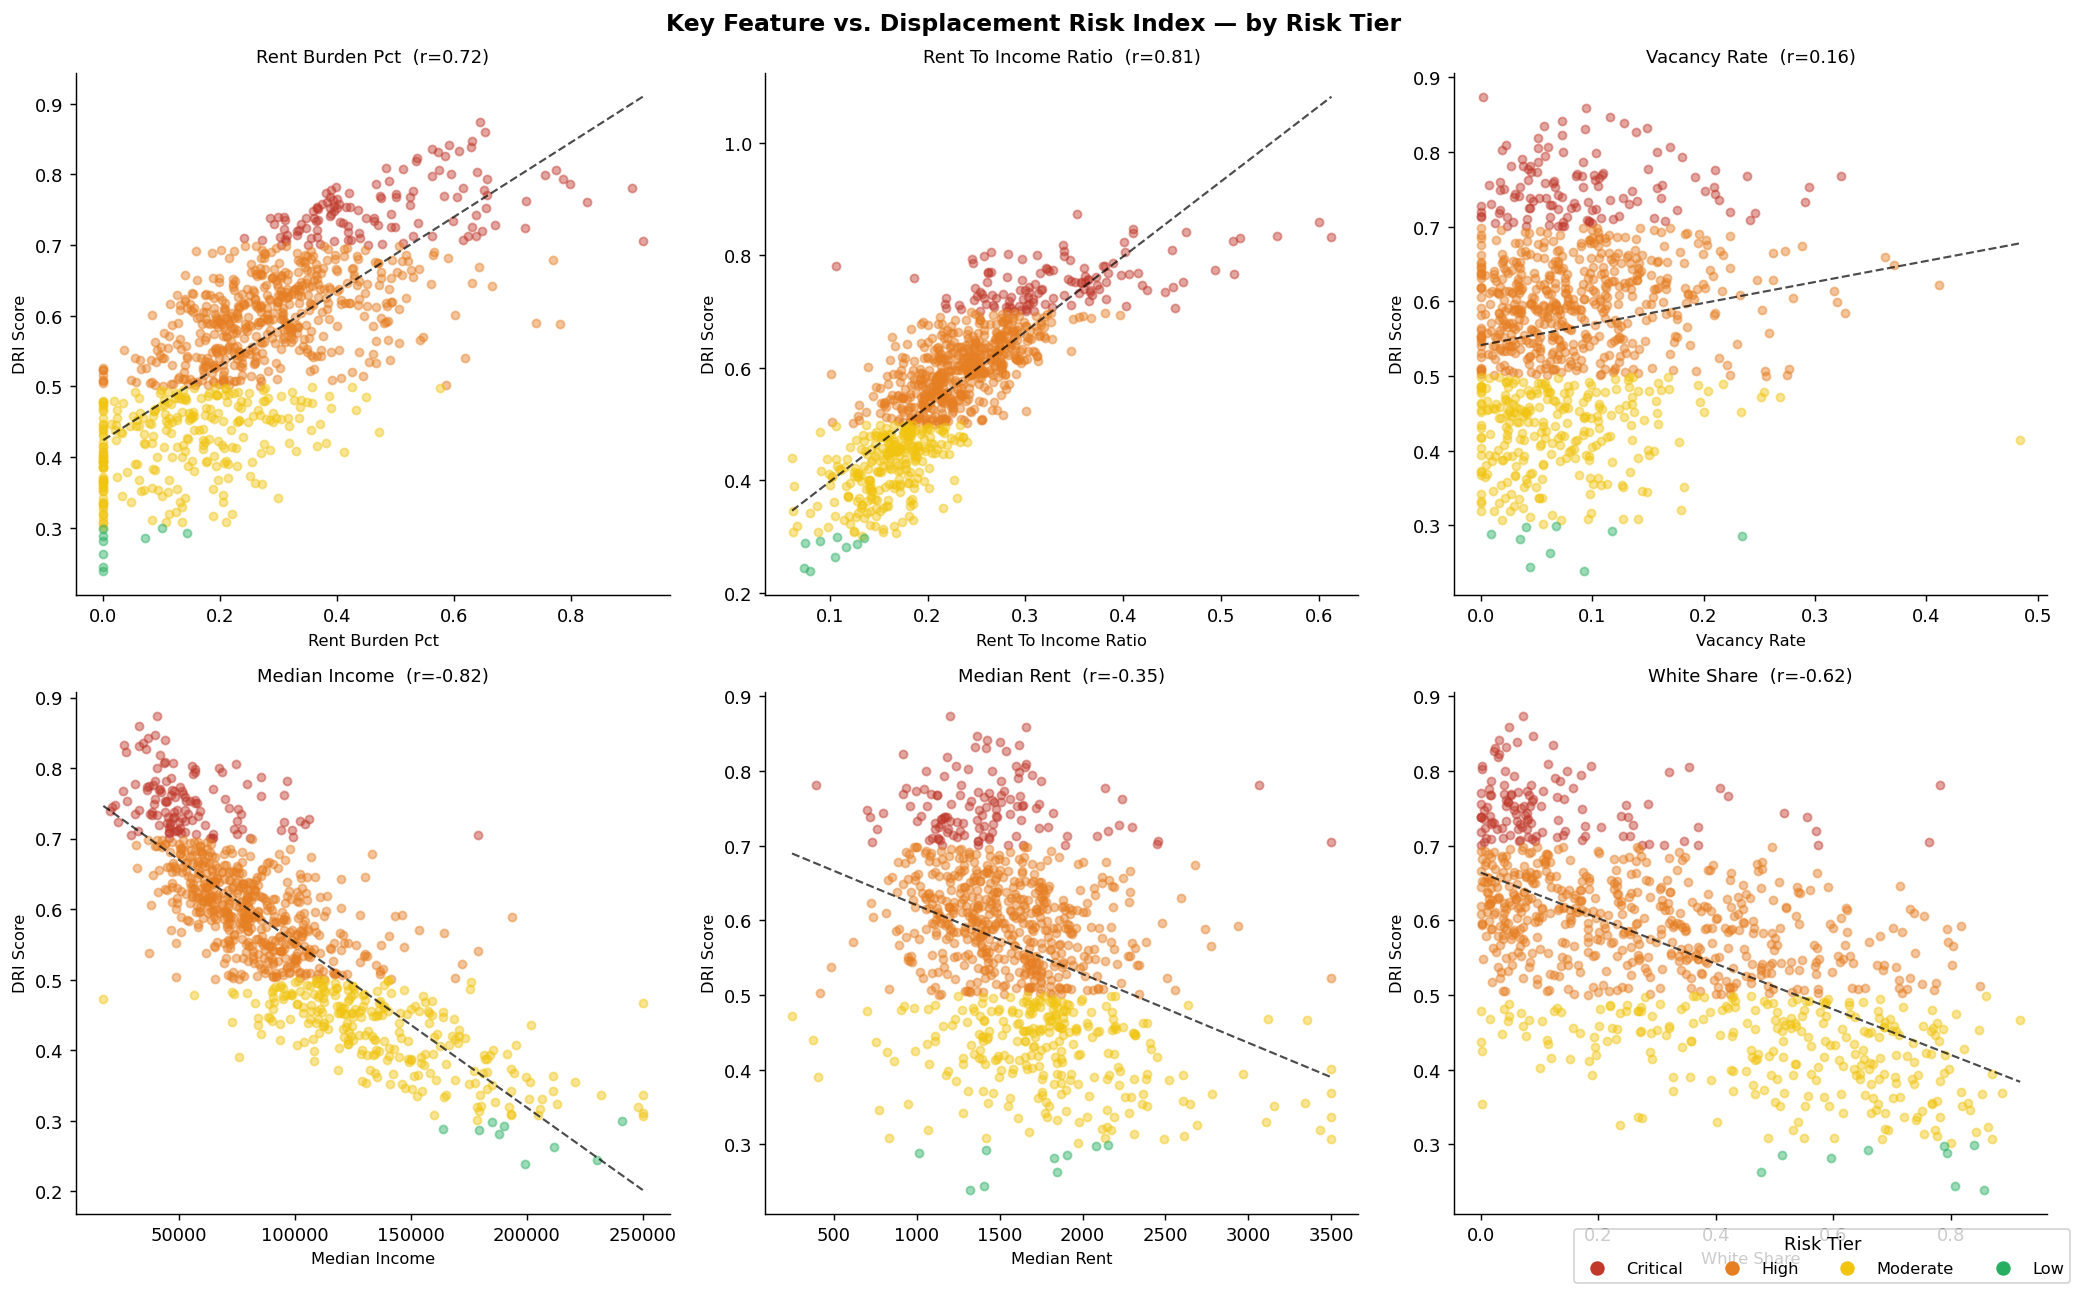

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Key Feature vs. Displacement Risk Index — by Risk Tier", fontsize=13, fontweight="bold")

tier_colors = {"Critical": "#c0392b", "High": "#e67e22", "Moderate": "#f1c40f", "Low": "#27ae60"}
scatter_cols = ["rent_burden_pct","rent_to_income_ratio","vacancy_rate",
                "median_income","median_rent","white_share"]

for ax, col in zip(axes.flat, scatter_cols):
    if col not in latest.columns or "displacement_risk_index" not in latest.columns:
        continue
    for tier, color in tier_colors.items():
        subset = latest[latest["risk_tier"] == tier]
        ax.scatter(subset[col], subset["displacement_risk_index"],
                   color=color, alpha=0.45, s=20, label=tier)
    # Regression line
    valid = latest[[col, "displacement_risk_index"]].dropna()
    m, b, r, p, _ = stats.linregress(valid[col], valid["displacement_risk_index"])
    x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(x_line, m*x_line + b, "k--", linewidth=1.2, alpha=0.7)
    ax.set_xlabel(col.replace("_"," ").title(), fontsize=9)
    ax.set_ylabel("DRI Score", fontsize=9)
    ax.set_title(f"{col.replace('_',' ').title()}  (r={r:.2f})", fontsize=10)

handles = [plt.Line2D([0],[0],marker="o",color=c,linestyle="",markersize=7,label=t)
           for t, c in tier_colors.items()]
fig.legend(handles=handles, title="Risk Tier", loc="lower right", ncol=4, fontsize=9)
plt.tight_layout()
plt.savefig("notebooks/eda_scatter.png", bbox_inches="tight")
plt.show()


## 7. Year-over-Year Panel Analysis

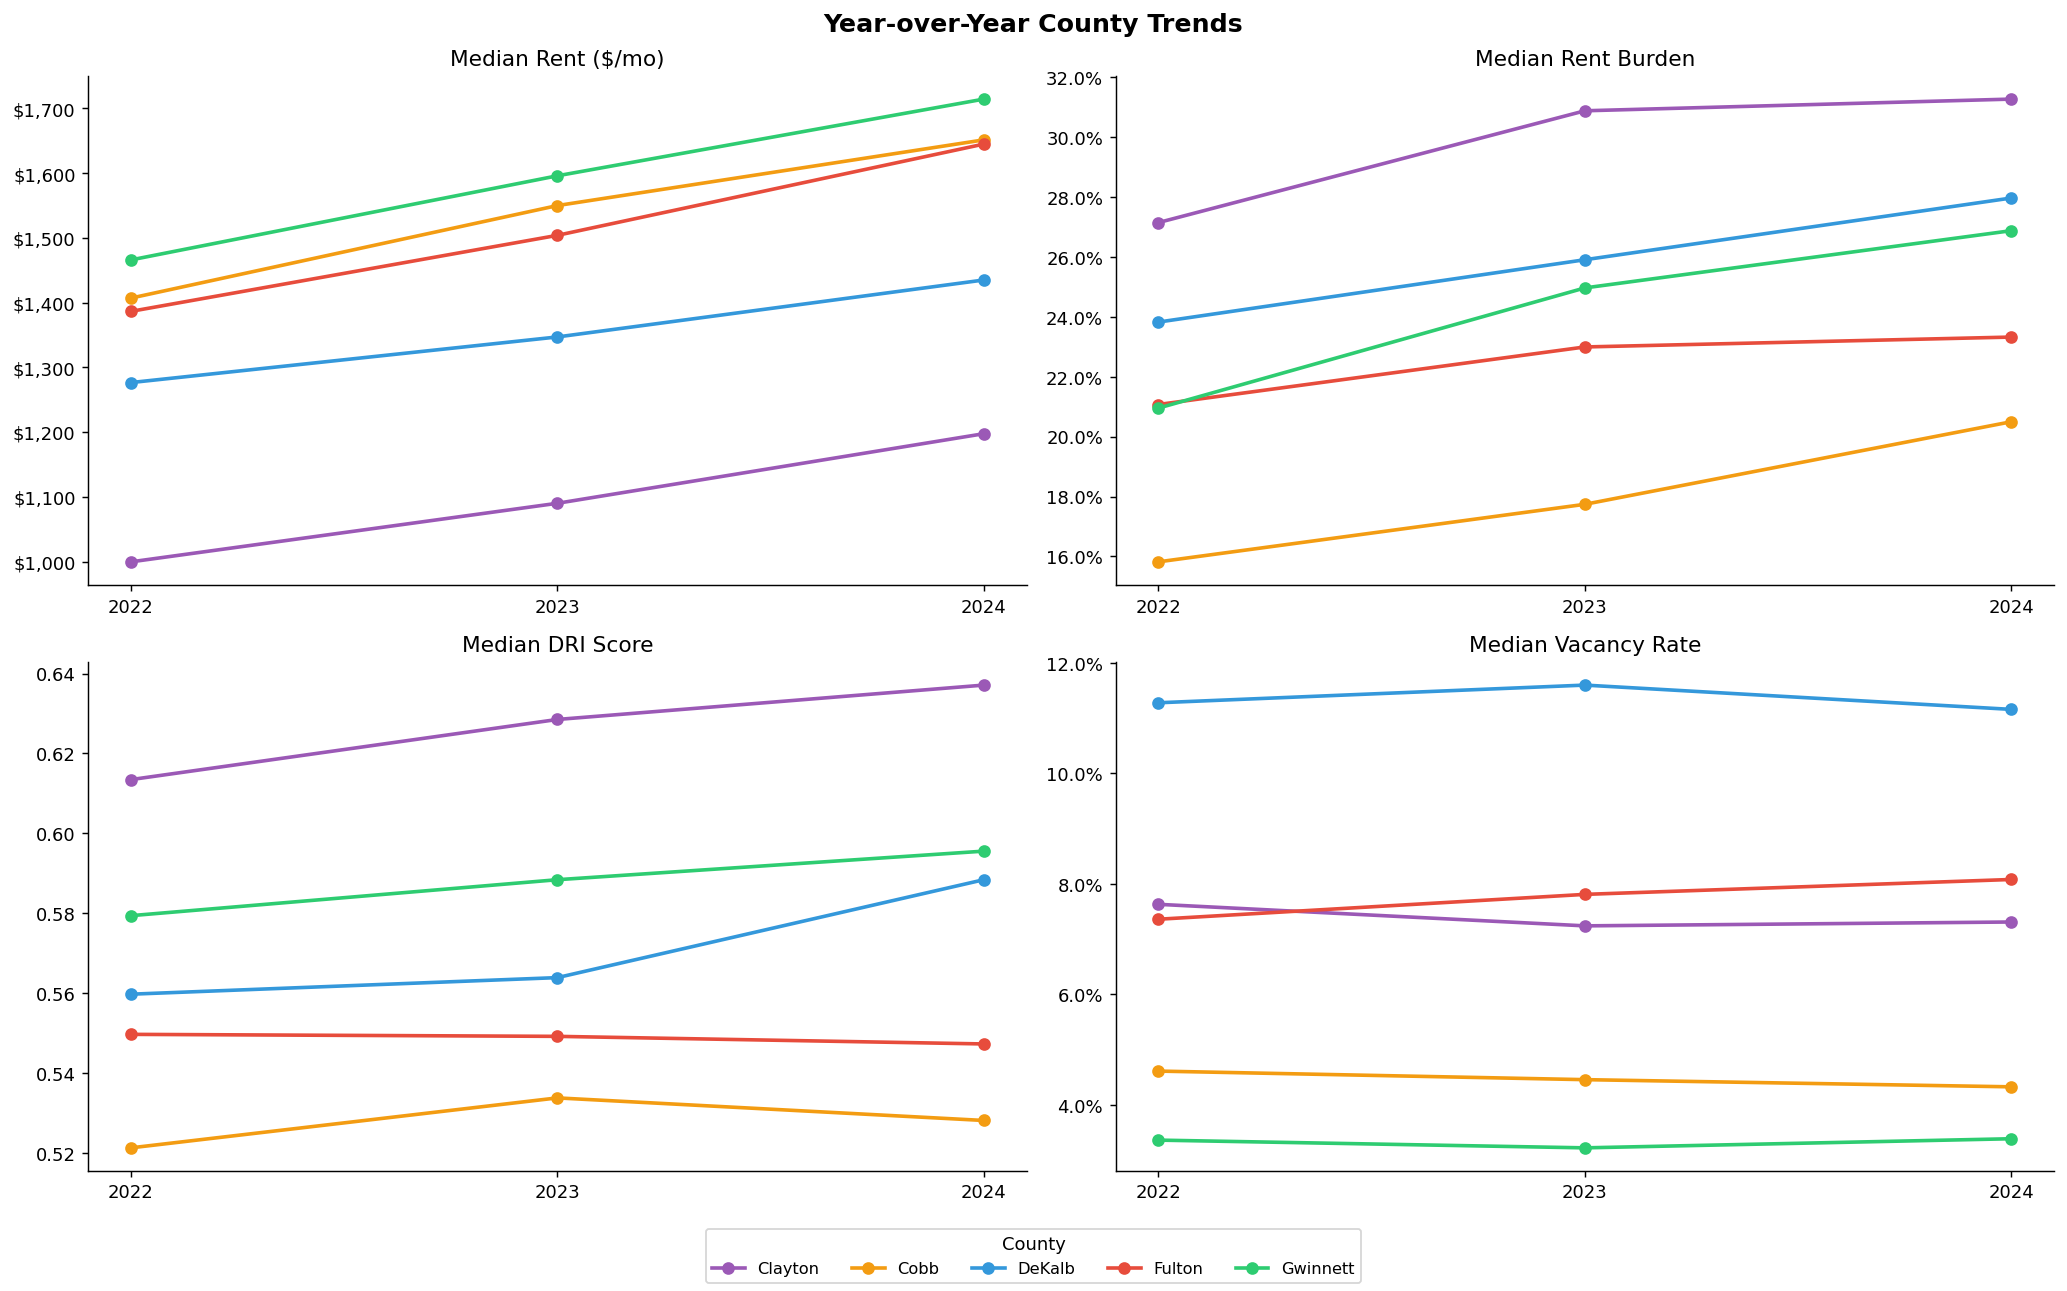

In [10]:
if "data_year" in df.columns and df["data_year"].nunique() > 1:
    yoy = df.groupby(["data_year","county_name"]).agg(
        median_rent=("median_rent","median"),
        rent_burden_pct=("rent_burden_pct","median"),
        dri=("displacement_risk_index","median"),
        vacancy_rate=("vacancy_rate","median")
    ).reset_index()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Year-over-Year County Trends", fontsize=14, fontweight="bold")
    county_colors = {"Fulton":"#e74c3c","DeKalb":"#3498db","Gwinnett":"#2ecc71",
                     "Cobb":"#f39c12","Clayton":"#9b59b6"}

    for ax, (col, label) in zip(axes.flat, [
        ("median_rent","Median Rent ($/mo)"),
        ("rent_burden_pct","Median Rent Burden"),
        ("dri","Median DRI Score"),
        ("vacancy_rate","Median Vacancy Rate"),
    ]):
        for county, grp in yoy.groupby("county_name"):
            grp = grp.sort_values("data_year")
            ax.plot(grp["data_year"], grp[col], marker="o", linewidth=2,
                    color=county_colors.get(county,"#888"), label=county)
        ax.set_title(label)
        ax.set_xticks(sorted(df["data_year"].unique()))
        if col == "median_rent":
            ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
        elif col in ["rent_burden_pct","vacancy_rate"]:
            ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="County", loc="lower center", ncol=5, fontsize=9)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig("notebooks/eda_yoy.png", bbox_inches="tight")
    plt.show()
else:
    print("Only one year available — re-run data_pipeline.py for multi-year data.")


## 8. FRED Macro Data — Context

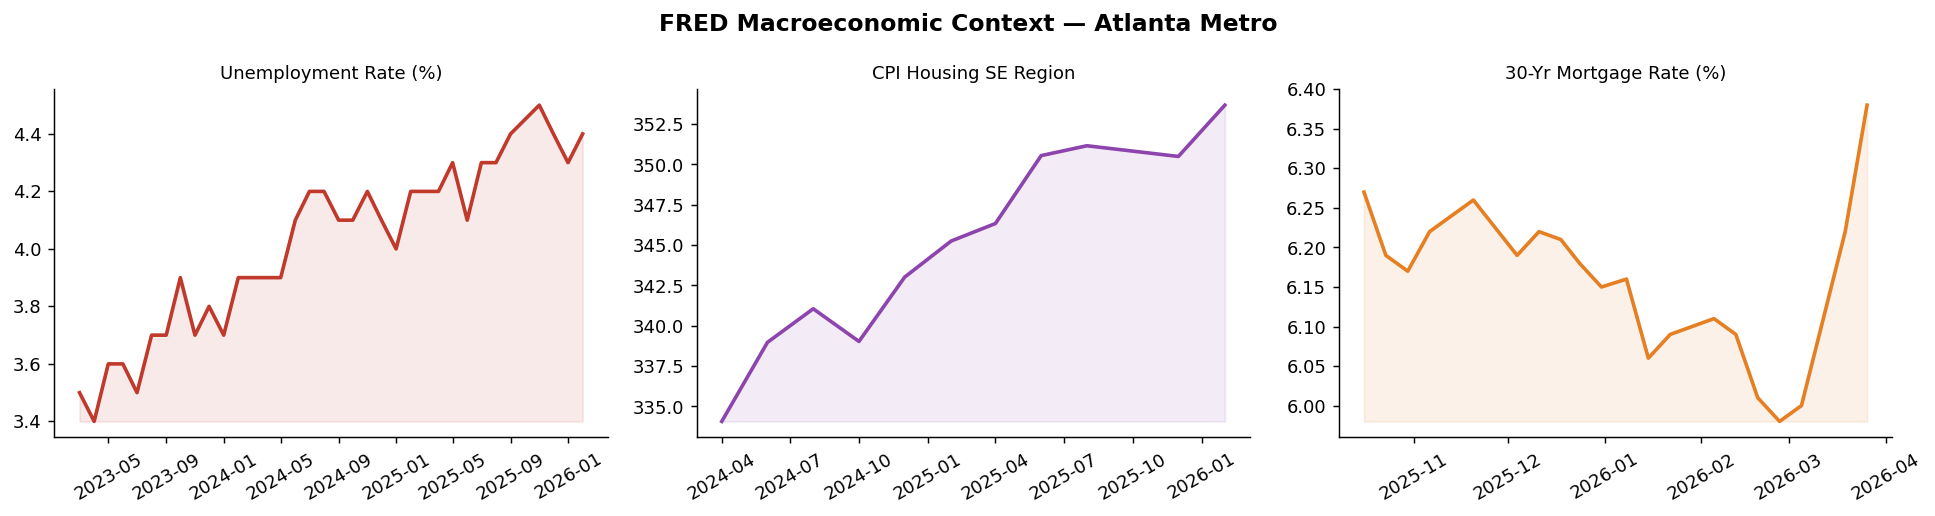

In [11]:
if fred_tables:
    n = len(fred_tables)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    fig.suptitle("FRED Macroeconomic Context — Atlanta Metro", fontsize=13, fontweight="bold")

    label_map = {
        "fred_labor_force_atlanta":       ("Labor Force Atlanta", "#2980b9"),
        "fred_unemployment_rate_atlanta":  ("Unemployment Rate (%)", "#c0392b"),
        "fred_cpi_housing_southeast":      ("CPI Housing SE Region", "#8e44ad"),
        "fred_mortgage_rate_30yr":         ("30-Yr Mortgage Rate (%)", "#e67e22"),
    }

    for ax, (tname, tdf) in zip(axes, fred_tables.items()):
        col = [c for c in tdf.columns if c != "date"][0]
        tdf["date"] = pd.to_datetime(tdf["date"])
        tdf = tdf.sort_values("date").dropna(subset=[col])
        label, color = label_map.get(tname, (col, "#555"))
        ax.plot(tdf["date"], tdf[col], color=color, linewidth=2)
        ax.fill_between(tdf["date"], tdf[col], tdf[col].min(), alpha=0.1, color=color)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig("notebooks/eda_fred.png", bbox_inches="tight")
    plt.show()
else:
    print("No FRED tables found. Run src/data_pipeline.py to ingest macro data.")


## 9. EDA Summary & Key Takeaways

### Statistical Findings

1. **Rent Burden is right-skewed** — a long tail of tracts where severely burdened households represent nearly the entire renter pool. These are the Critical-tier tracts.

2. **Median Income and DRI are strongly negatively correlated** — the lower the income, the higher the displacement risk, confirming income-driven housing insecurity is the dominant force.

3. **Vacancy Rate acts as a pressure valve** — low-vacancy tracts cluster in High/Critical tiers, confirming supply constraints amplify rent pressure.

4. **County heterogeneity is substantial** — Fulton and DeKalb show significantly higher rent burdens than Gwinnett and Cobb, reflecting structural differences in housing stock and demographic composition.

5. **Rent-to-Income Ratio > 0.30 is a near-universal marker** of High or Critical status, reinforcing the federal 30% housing cost burden threshold as an appropriate intervention trigger.

### Data Quality Notes
- Negative values were coerced to `NA` during pipeline ingestion
- ACS 5-year estimates introduce a temporal smoothing effect — single-year spikes are muted
- FRED series have different release lags; mortgage rate and CPI data may trail census vintage by 2–3 months
